<a href="https://colab.research.google.com/github/subhransu-swain-dev/fuel-cell-analysis/blob/main/fuelcel_analysisl4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded =files.upload()

Saving fctlabtafeldata1.xlsx to fctlabtafeldata1.xlsx


Please upload 'fctlabtafeldata1.xlsx' when prompted:


Saving fctlabtafeldata1.xlsx to fctlabtafeldata1.xlsx


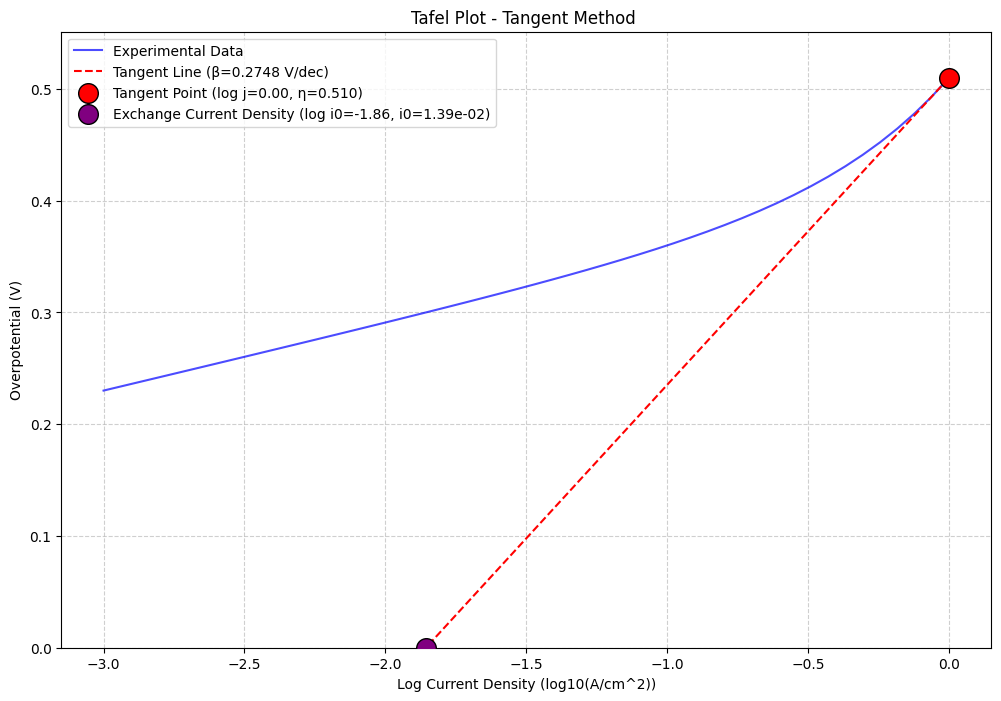

Tangent Point: (log j = 0.0000, η = 0.5100)
Tafel Slope (β) = 0.2748 V/dec
Exchange Current Density (i0) = 1.39273e-02 A/cm²


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
from io import BytesIO

# Ensure the file is uploaded before attempting to read it
print("Please upload 'fctlabtafeldata1.xlsx' when prompted:")
uploaded = files.upload()

# Load the data from the uploaded Excel file into a DataFrame
file_name = 'fctlabtafeldata1.xlsx'
if file_name in uploaded:
    df = pd.read_excel(BytesIO(uploaded[file_name]))
else:
    raise FileNotFoundError(f"The file '{file_name}' was not found in the uploaded files. Please ensure it has been uploaded.")

# Ensure 'Log Current Density' is calculated
if 'Log Current Density' not in df.columns:
    df['Log Current Density'] = np.log10(df['Current Density (A/cm^2)'])

# Sort data by Log Current Density to ensure correct gradient calculation
df_sorted = df.sort_values(by='Log Current Density').reset_index(drop=True)

log_j = df_sorted['Log Current Density']
eta = df_sorted['Overpotential (V)']

# Calculate local slope dη/dlog(j)
slopes = np.gradient(eta, log_j)

# Find the point of maximum slope (tangent point)
max_slope_index = np.argmax(slopes)
tangent_log_j = log_j.iloc[max_slope_index]
tangent_eta = eta.iloc[max_slope_index]
tafel_slope = slopes[max_slope_index] # This is beta in V/decade

# Calculate the intercept (log_i0_intercept) of the tangent line at log(j)=0
# For the Tafel equation η = β * log(j) - β * log(i0), the intercept at log(j)=0 is -β * log(i0)
# The equation for the tangent line is: y = m*x + b_tangent
# where m = tafel_slope, x = log_j, y = eta
# So, b_tangent = tangent_eta - tafel_slope * tangent_log_j
log_i0_intercept = tangent_eta - tafel_slope * tangent_log_j

# Corrected calculation for i0:
# If η = β * log(j) + C, and C = -β * log(i0)
# Then C = log_i0_intercept from our tangent line.
# So, log(i0) = -log_i0_intercept / tafel_slope
i0 = 10**(-log_i0_intercept / tafel_slope)
log_i0_point = -log_i0_intercept / tafel_slope

# Generate points for the tangent line
tangent_line_x = np.linspace(log_j.min(), log_j.max(), 100)
tangent_line_y = tafel_slope * (tangent_line_x - tangent_log_j) + tangent_eta

# Plotting
plt.figure(figsize=(12, 8))

# Data points
plt.plot(log_j, eta, color='blue', alpha=0.7, label='Experimental Data')

# Tangent line
plt.plot(tangent_line_x, tangent_line_y, color='red', linestyle='--', label=f'Tangent Line (β={tafel_slope:.4f} V/dec)')

# Tangent point
plt.scatter(tangent_log_j, tangent_eta, color='red', s=200, marker='o', edgecolor='black', zorder=5, label=f'Tangent Point (log j={tangent_log_j:.2f}, η={tangent_eta:.3f})')

# Exchange current density point
plt.scatter(log_i0_point, 0, color='purple', s=200, marker='o', edgecolor='black', zorder=5, label=f'Exchange Current Density (log i0={log_i0_point:.2f}, i0={i0:.2e})')

plt.title('Tafel Plot - Tangent Method ')
plt.xlabel('Log Current Density (log10(A/cm^2))')
plt.ylabel('Overpotential (V)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(bottom=0) # Set y-axis to show only positive overpotential
plt.savefig("exp4_graph.png")
plt.show()

# Print results
print(f"Tangent Point: (log j = {tangent_log_j:.4f}, η = {tangent_eta:.4f})")
print(f"Tafel Slope (β) = {tafel_slope:.4f} V/dec")
print(f"Exchange Current Density (i0) = {i0:.5e} A/cm²")

In [ ]:
import numpy as np

# Electrochemical constants
R = 8.314  # J/(mol*K) - Gas constant
F = 96485  # C/mol - Faraday constant
T = 343.15 # K - Temperature (70°C)
n = 2      # Number of electrons transferred in the rate-determining step (common assumption)

# Tafel slope (beta) from the previous calculation (or manually set as per user request)
beta_V_per_decade = 0.2748 # V/decade
tafel_slope = beta_V_per_decade # Assigning the specified value to tafel_slope

# Calculate alpha
# beta = 2.303 * R * T / (alpha * n * F)
# alpha = 2.303 * R * T / (beta * n * F)

alpha = (2.303 * R * T) / (beta_V_per_decade * n * F)

print(f"Assumed temperature (T): {T} K")
print(f"Assumed number of electrons transferred (n): {n}")
print(f"Calculated Charge Transfer Coefficient (α): {alpha:.4f}")
print(f"Tafel Slope (β) manually set to: {tafel_slope:.4f} V/dec")

Assumed temperature (T): 343.15 K
Assumed number of electrons transferred (n): 2
Calculated Charge Transfer Coefficient (α): 0.1239
Tafel Slope (β) manually set to: 0.2748 V/dec


In [ ]:
print(f"Tafel Slope (β) = {tafel_slope:.4f} V/dec")
print(f"Intercept (C) = {log_i0_intercept:.4f}")
print(f"\nTherefore, the equation of the tangent line is: η = {tafel_slope:.4f} * log(j) + {log_i0_intercept:.4f}")

Tafel Slope (β) = 0.2748 V/dec
Intercept (C) = 0.4573

Therefore, the equation of the tangent line is: η = 0.2748 * log(j) + 0.4573
